Dati caricati con successo: 40000 righe
Dati caricati con successo: 40000 righe
Agenti unici identificati: 20000
Decisioni di emigrazione registrate: 290
Osservazioni totali per analisi longitudinali: 40000
Caratteristiche iniziali agenti: 20000
Tasso emigrazione lifetime: 1.4%


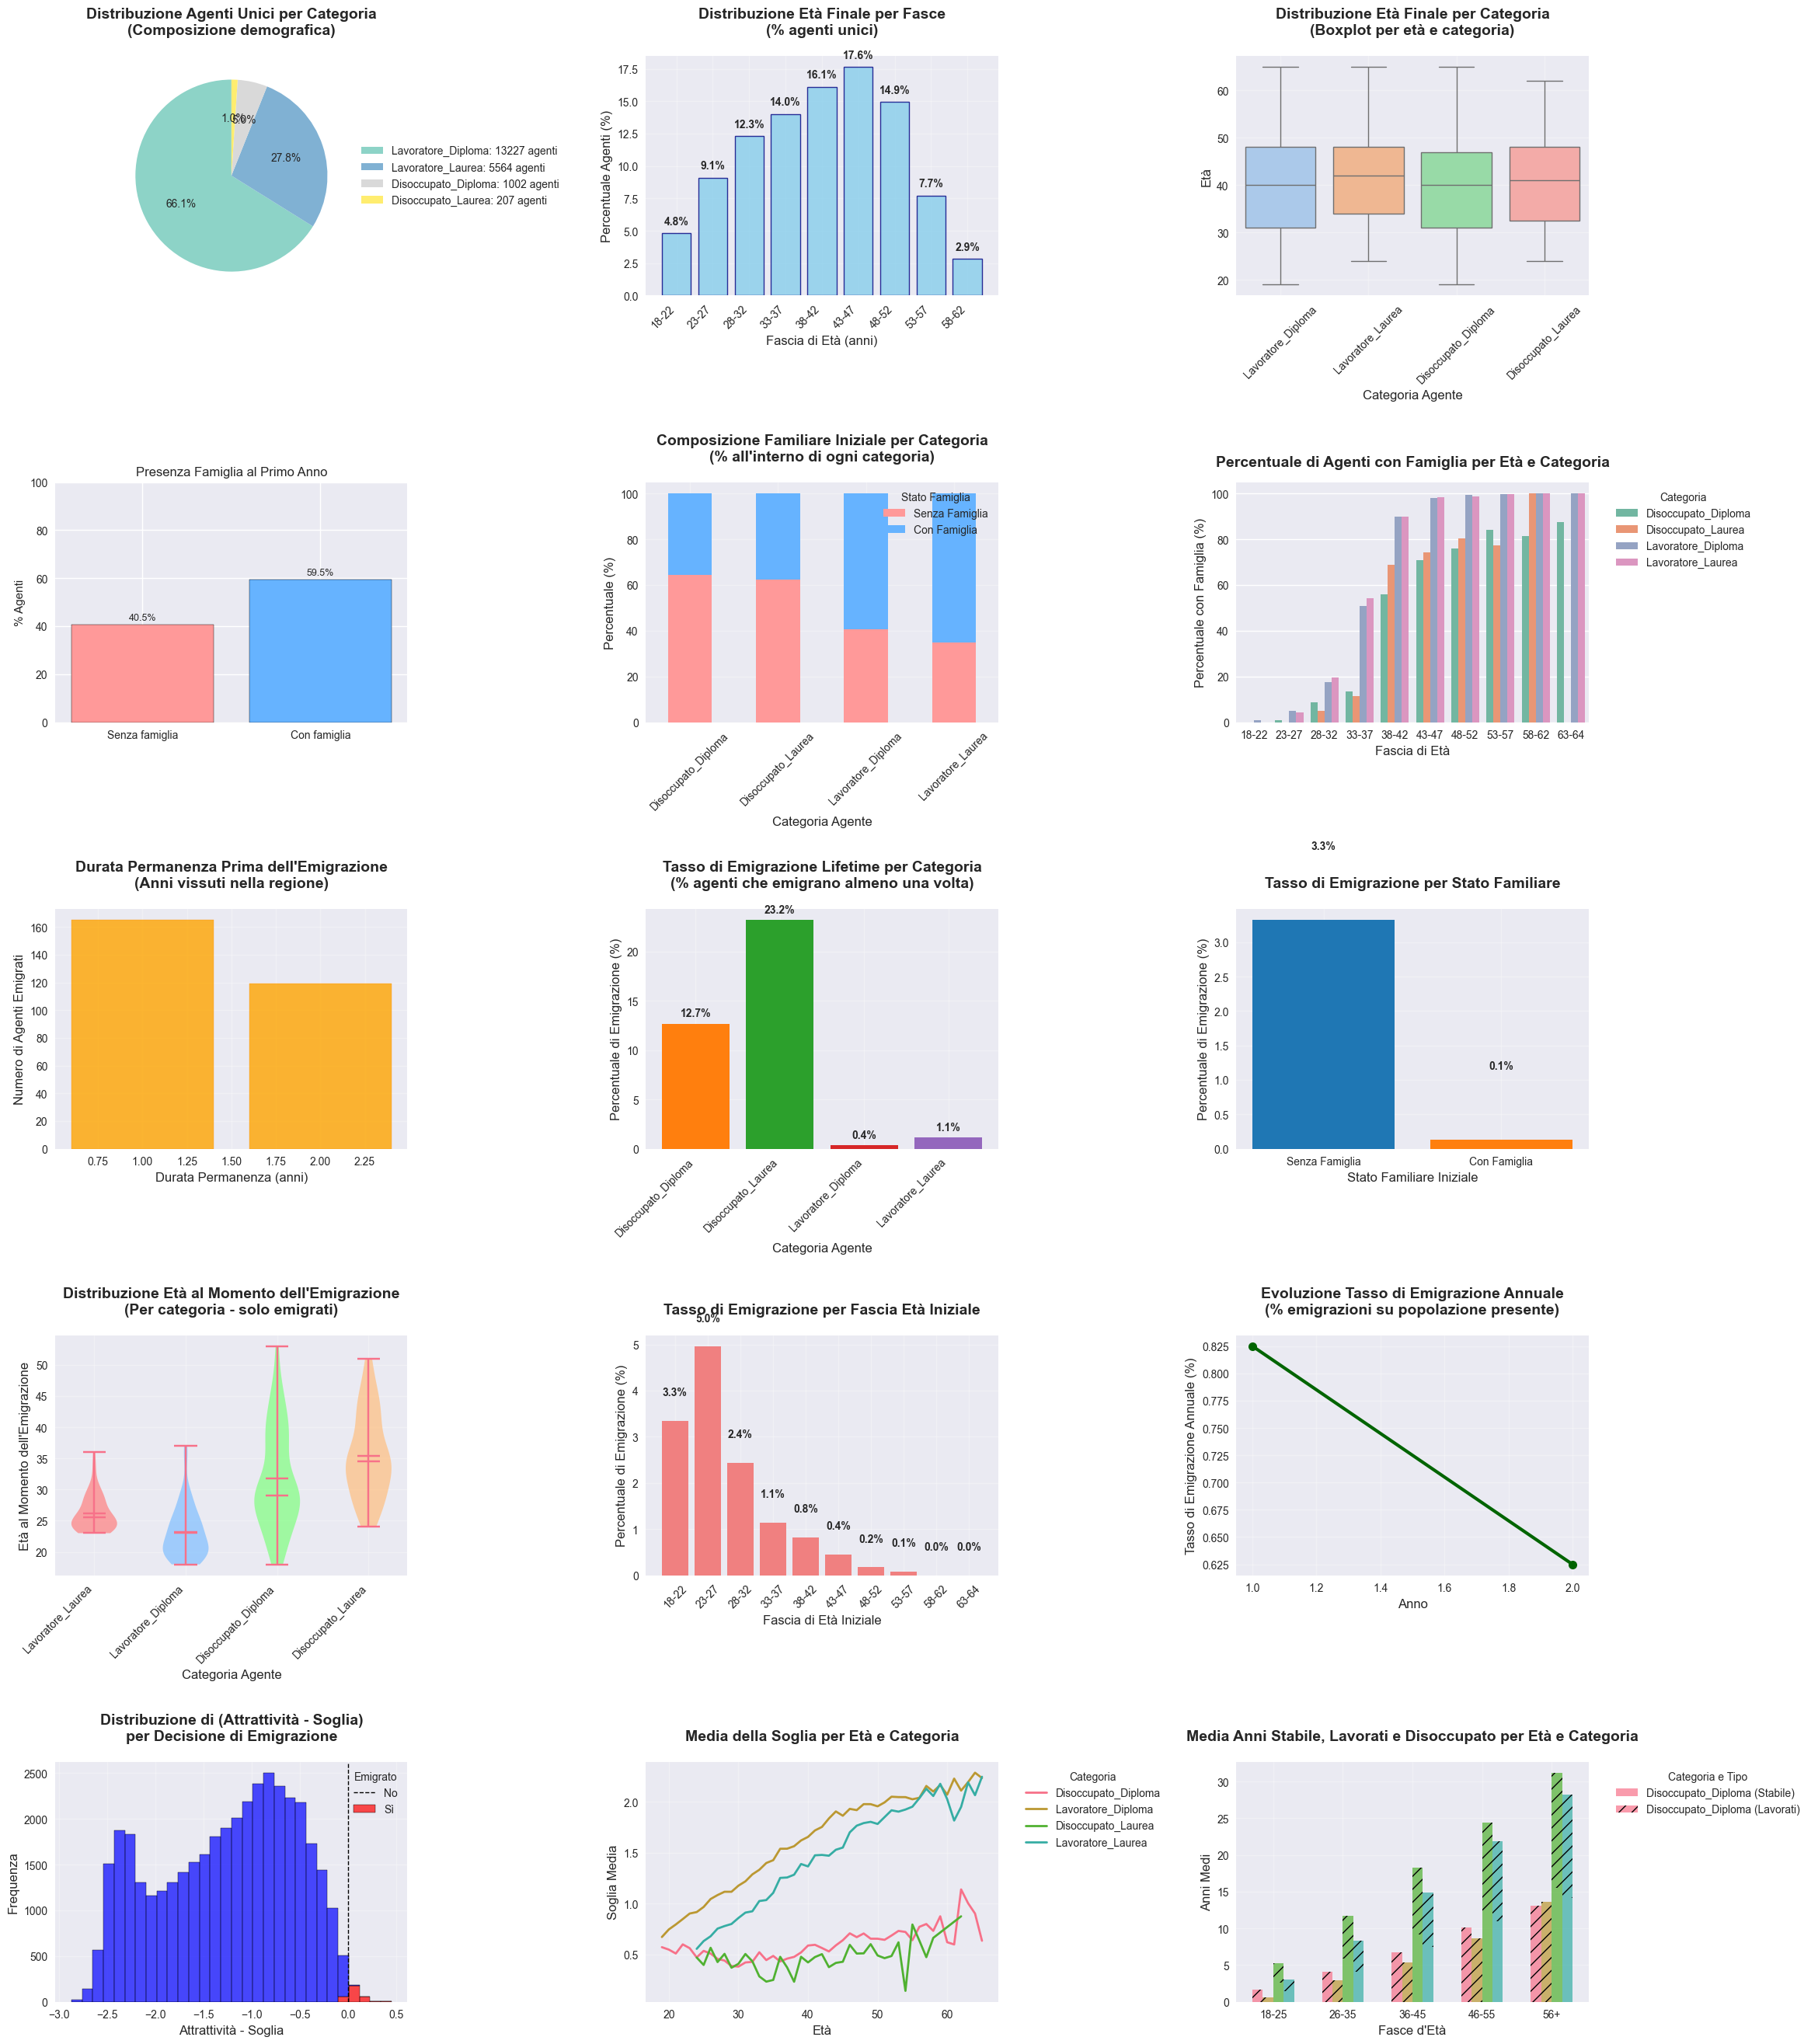

In [37]:
# Analisi Dati Migrazione - log.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Configurazione per visualizzazioni
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ============================================================================
# PARAMETRI
# ============================================================================

N_AGENTI_PER_REGIONE = 1000 #Numero di agenti per regione
PERCENTUALE_SOGLIA = 1000    # Soglia percentuale per analisi 
ETA_MIN = 18              # Età minima agenti
ETA_MAX = 64              # Età massima agenti
N_CATEGORIE = 4           # Numero di categorie

COORDINATE_REGIONI = {
    'Abruzzo': (42.3511, 13.3994),
    'Basilicata': (40.6401, 15.8063),
    'Calabria': (39.3094, 16.2518),
    'Campania': (40.8359, 14.2488),
    'Emilia-Romagna': (44.4949, 11.3426),
    'Friuli-Venezia Giulia': (45.6361, 13.8047),
    'Lazio': (41.9028, 12.4964),
    'Liguria': (44.4056, 8.9463),
    'Lombardia': (45.4642, 9.1900),
    'Marche': (43.6158, 13.5189),
    'Molise': (41.7010, 14.4722),
    'Piemonte': (45.0703, 7.6869),
    'Puglia': (41.1257, 16.8765),
    'Sardegna': (40.1209, 9.0129),
    'Sicilia': (37.5999, 14.0154),
    'Toscana': (43.7711, 11.2486),
    'Trentino-Alto Adige': (46.4982, 11.3548),
    'Umbria': (42.9382, 12.6144),
    'Valle d\'Aosta': (45.7383, 7.3514),
    'Veneto': (45.4398, 12.3317)
}

# ============================================================================
# CARICAMENTO E PREPARAZIONE 
# ============================================================================


try:
    df_raw = pd.read_csv('../data/log.csv')
    print(f"Dati caricati con successo: {len(df_raw)} righe")
except FileNotFoundError:
    print("File log.csv non trovato nella cartella superiore")
except Exception as e:
    print(f"Errore nel caricamento: {e}")

# Gestione valori mancanti
if df_raw.isnull().sum().sum() > 0:
    print("Valori mancanti trovati:")
    print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
    df_raw = df_raw.dropna()
    print(f"Righe dopo pulizia: {len(df_raw)}")






try:
    df_raw = pd.read_csv('../data/log.csv')
    print(f"Dati caricati con successo: {len(df_raw)} righe")
except FileNotFoundError:
    print("File log.csv non trovato nella cartella superiore")
except Exception as e:
    print(f"Errore nel caricamento: {e}")

# Gestione valori mancanti
if df_raw.isnull().sum().sum() > 0:
    print("Valori mancanti trovati:")
    print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
    df_raw = df_raw.dropna()
    print(f"Righe dopo pulizia: {len(df_raw)}")


# 1. DATASET AGENTI UNICI (per analisi demografiche)
# Prendiamo l'ultima osservazione di ogni agente per avere dati demografici finali
df_agenti_unici = df_raw.sort_values(['id_agente', 'anno']).groupby('id_agente').last().reset_index()
print(f"Agenti unici identificati: {len(df_agenti_unici)}")

# 2. DATASET DECISIONI MIGRATORIE (solo righe con emigrato=True)
df_emigrazioni = df_raw[df_raw['emigrato'] == True].copy()
print(f"Decisioni di emigrazione registrate: {len(df_emigrazioni)}")

# 3. DATASET COMPLETO per analisi temporali
df_longitudinale = df_raw.copy()
print(f"Osservazioni totali per analisi longitudinali: {len(df_longitudinale)}")

# 4. DATASET PER SURVIVAL ANALYSIS (primo anno di ogni agente)
df_primo_anno = df_raw.sort_values(['id_agente', 'anno']).groupby('id_agente').first().reset_index()
print(f"Caratteristiche iniziali agenti: {len(df_primo_anno)}")

# Calcoliamo chi ha mai emigrato nella sua "vita"
agenti_emigrati = set(df_emigrazioni['id_agente'].unique())
df_agenti_unici['mai_emigrato'] = df_agenti_unici['id_agente'].isin(agenti_emigrati)
df_primo_anno['mai_emigrato'] = df_primo_anno['id_agente'].isin(agenti_emigrati)

# Creazione fasce d'età sui dati unici
bins = [17, 22, 27, 32, 37, 42, 47, 52, 57, 62, 65]
labels = ['18-22', '23-27', '28-32', '33-37', '38-42', '43-47', '48-52', '53-57', '58-62', '63-64']
df_agenti_unici['fascia_eta'] = pd.cut(df_agenti_unici['eta'], bins=bins, labels=labels, include_lowest=True)
df_primo_anno['fascia_eta'] = pd.cut(df_primo_anno['eta'], bins=bins, labels=labels, include_lowest=True)

print(f"Tasso emigrazione lifetime: {df_agenti_unici['mai_emigrato'].mean()*100:.1f}%")

# ============================================================================
# VISUALIZZAZIONI STATICHE - ANALISI LONGITUDINALE CORRETTA
# ============================================================================

"""Dashboard con analisi corretta per dati longitudinali"""

fig = plt.figure(figsize=(24, 32))

# =============================================================================
# SEZIONE 1: ANALISI DEMOGRAFICA GENERALE (su agenti unici)
# =============================================================================

# 1. Distribuzione categorie (su agenti unici)
ax1 = plt.subplot(6, 3, 1)
cat_counts = df_agenti_unici['categoria'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(cat_counts)))
wedges, texts, autotexts = ax1.pie(cat_counts.values, labels=None, 
                                    autopct='%1.1f%%', startangle=90, colors=colors)
ax1.legend(wedges, [f'{cat}: {count} agenti' for cat, count in cat_counts.items()], 
        loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
ax1.set_title('Distribuzione Agenti Unici per Categoria\n(Composizione demografica)', 
            fontsize=14, fontweight='bold', pad=20)

# 2. Distribuzione età finale in fasce quinquennali
ax2 = plt.subplot(6, 3, 2)
# Età massima inclusa: 64 anni
df_età_filtrato = df_agenti_unici[df_agenti_unici['eta'] <= 65]

# Nuovi bin: da 18 a 65 escluso (quindi ultimo bin sarà 60-64)
bins_età = np.arange(18, 65, 5)
counts, bin_edges = np.histogram(df_età_filtrato['eta'], bins=bins_età)
percentuali = (counts / len(df_età_filtrato)) * 100
labels_età = [f'{int(bin_edges[i])}-{int(bin_edges[i+1]-1)}' for i in range(len(bin_edges)-1)]

ax2 = plt.subplot(6, 3, 2)
bars = ax2.bar(range(len(percentuali)), percentuali, alpha=0.8, color='skyblue', 
            edgecolor='navy', linewidth=1)
ax2.set_title('Distribuzione Età Finale per Fasce\n(% agenti unici)', 
            fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Fascia di Età (anni)', fontsize=12)
ax2.set_ylabel('Percentuale Agenti (%)', fontsize=12)
ax2.set_xticks(range(len(labels_età)))
ax2.set_xticklabels(labels_età, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, percentuali)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')


#  GRAFICO 3: Distribuzione età per categoria
ax3 = plt.subplot(6, 3, 3)
sns.boxplot(data=df_agenti_unici, x='categoria', y='eta', palette='pastel', ax=ax3)
ax3.set_title('Distribuzione Età Finale per Categoria\n(Boxplot per età e categoria)', 
            fontsize=14, fontweight='bold', pad=20)
ax3.set_xlabel('Categoria Agente', fontsize=12)
ax3.set_ylabel('Età', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)



# 4. Percentuale con/senza famiglia al primo anno (usando df_primo_anno)
ax4 = plt.subplot(6, 3, 4)
famiglia_counts = df_primo_anno['famiglia'].value_counts().sort_index()
labels = ['Senza famiglia', 'Con famiglia']
values = [famiglia_counts.get(0, 0), famiglia_counts.get(1, 0)]
percentuali = [v / sum(values) * 100 for v in values]
bar_colors = ['#FF9999', '#66B3FF']
bars = ax4.bar(labels, percentuali, color=bar_colors, edgecolor='black')

# Etichette sopra le barre
for bar, perc in zip(bars, percentuali):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{perc:.1f}%", 
             ha='center', va='bottom', fontsize=9)
ax4.set_ylim(0, 100)
ax4.set_ylabel('% Agenti')
ax4.set_title('Presenza Famiglia al Primo Anno')



# Distribuzione famiglia per categoria (caratteristiche iniziali)
ax6 = plt.subplot(6, 3, 5)
df_cat_fam = df_primo_anno.groupby(['categoria', 'famiglia']).size().unstack(fill_value=0)
df_cat_fam_pct = df_cat_fam.div(df_cat_fam.sum(axis=1), axis=0) * 100

df_cat_fam_pct.plot(kind='bar', stacked=True, ax=ax6, color=['#ff9999', '#66b3ff'])
ax6.set_title('Composizione Familiare Iniziale per Categoria\n(% all\'interno di ogni categoria)', 
            fontsize=14, fontweight='bold', pad=20)
ax6.set_xlabel('Categoria Agente', fontsize=12)
ax6.set_ylabel('Percentuale (%)', fontsize=12)
ax6.legend(['Senza Famiglia', 'Con Famiglia'], title='Stato Famiglia')
ax6.tick_params(axis='x', rotation=45)
ax6.grid(True, alpha=0.3)


df_agenti_unici['famiglia'] = df_agenti_unici['famiglia'].astype(int)

# Calcola la media (percentuale) di agenti con famiglia per fascia_eta, categoria, e regione (origine)
grouped = df_agenti_unici.groupby(['fascia_eta', 'categoria', 'origine'])['famiglia'].mean().reset_index()
grouped['percentuale_famiglia'] = grouped['famiglia'] * 100

# Posizioniamo il grafico come subplot 12 (riga 4, colonna 3)
ax12 = plt.subplot(6, 3, 6)

sns.barplot(
    data=grouped,
    x='fascia_eta',
    y='percentuale_famiglia',
    hue='categoria',
    palette='Set2',
    errorbar=None,
    ax=ax12
)

ax12.set_title('Percentuale di Agenti con Famiglia per Età e Categoria', fontsize=14, fontweight='bold', pad=15)
ax12.set_xlabel('Fascia di Età', fontsize=12)
ax12.set_ylabel('Percentuale con Famiglia (%)', fontsize=12)
ax12.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')


# =============================================================================
# SEZIONE 2: ANALISI SURVIVAL/DURATA PERMANENZA
# =============================================================================

# 4. Distribuzione durata permanenza per agenti emigrati
ax4 = plt.subplot(6, 3, 7)
# Calcoliamo per ogni agente emigrato, quanti anni è rimasto
durata_permanenza = []
for agente in agenti_emigrati:
    osservazioni_agente = df_raw[df_raw['id_agente'] == agente].sort_values('anno')
    anno_emigrazione = osservazioni_agente[osservazioni_agente['emigrato'] == True]['anno'].iloc[0]
    primo_anno = osservazioni_agente['anno'].min()
    durata = anno_emigrazione - primo_anno + 1  # +1 perché include l'anno di emigrazione
    durata_permanenza.append(durata)

durata_counts = Counter(durata_permanenza)
anni = sorted(durata_counts.keys())
frequenze = [durata_counts[anno] for anno in anni]

bars = ax4.bar(anni, frequenze, alpha=0.8, color='orange', edgecolor='darkorange')
ax4.set_title('Durata Permanenza Prima dell\'Emigrazione\n(Anni vissuti nella regione)', 
            fontsize=14, fontweight='bold', pad=20)
ax4.set_xlabel('Durata Permanenza (anni)', fontsize=12)
ax4.set_ylabel('Numero di Agenti Emigrati', fontsize=12)
ax4.grid(True, alpha=0.3)


# =============================================================================
# SEZIONE 3: ANALISI PATTERN MIGRATORI (lifetime migration)
# =============================================================================

# 7. Tasso emigrazione lifetime per categoria
ax7 = plt.subplot(6, 3, 8)
emigrazione_cat = df_agenti_unici.groupby('categoria')['mai_emigrato'].mean() * 100
bars = ax7.bar(range(len(emigrazione_cat)), emigrazione_cat.values, 
                color=['#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
ax7.set_title('Tasso di Emigrazione Lifetime per Categoria\n(% agenti che emigrano almeno una volta)', 
            fontsize=14, fontweight='bold', pad=20)
ax7.set_xlabel('Categoria Agente', fontsize=12)
ax7.set_ylabel('Percentuale di Emigrazione (%)', fontsize=12)
ax7.set_xticks(range(len(emigrazione_cat)))
ax7.set_xticklabels(emigrazione_cat.index, rotation=45, ha='right')
ax7.grid(True, alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, emigrazione_cat.values)):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# 9. Emigrazione per stato familiare iniziale
ax9 = plt.subplot(6, 3, 9)
emigrazione_famiglia = df_primo_anno.groupby('famiglia')['mai_emigrato'].mean() * 100
bars = ax9.bar(['Senza Famiglia', 'Con Famiglia'], emigrazione_famiglia.values, 
                color=['#1f77b4', '#ff7f0e'])
ax9.set_title('Tasso di Emigrazione per Stato Familiare', 
            fontsize=14, fontweight='bold', pad=20)
ax9.set_xlabel('Stato Familiare Iniziale', fontsize=12)
ax9.set_ylabel('Percentuale di Emigrazione (%)', fontsize=12)
ax9.grid(True, alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, emigrazione_famiglia.values)):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')


# 11. Distribuzione età al momento dell'emigrazione
ax11 = plt.subplot(6, 3, 10)
if len(df_emigrazioni) > 0:
    categories = df_emigrazioni['categoria'].unique()
    colors_violin = ['#ff7f7f', '#7fbfff', '#7fff7f', '#ffbf7f']
    
    data_by_cat = [df_emigrazioni[df_emigrazioni['categoria'] == cat]['eta'].values for cat in categories]
    parts = ax11.violinplot(data_by_cat, positions=range(len(categories)), 
                        showmeans=True, showmedians=True)
    
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors_violin[i % len(colors_violin)])
        pc.set_alpha(0.7)
    
    ax11.set_title('Distribuzione Età al Momento dell\'Emigrazione\n(Per categoria - solo emigrati)', 
                fontsize=14, fontweight='bold', pad=20)
    ax11.set_xlabel('Categoria Agente', fontsize=12)
    ax11.set_ylabel('Età al Momento dell\'Emigrazione', fontsize=12)
    ax11.set_xticks(range(len(categories)))
    ax11.set_xticklabels(categories, rotation=45, ha='right')
    ax11.grid(True, alpha=0.3)


# 8. Tasso emigrazione per fascia d'età iniziale
ax8 = plt.subplot(6, 3, 11)
emigrazione_fascia = df_primo_anno.groupby('fascia_eta')['mai_emigrato'].mean() * 100
bars = ax8.bar(range(len(emigrazione_fascia)), emigrazione_fascia.values, color='lightcoral')
ax8.set_title('Tasso di Emigrazione per Fascia Età Iniziale', 
            fontsize=14, fontweight='bold', pad=20)
ax8.set_xlabel('Fascia di Età Iniziale', fontsize=12)
ax8.set_ylabel('Percentuale di Emigrazione (%)', fontsize=12)
ax8.set_xticks(range(len(emigrazione_fascia)))
ax8.set_xticklabels(emigrazione_fascia.index, rotation=45)
ax8.grid(True, alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, emigrazione_fascia.values)):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')


# 10. Timeline emigrazioni per anno
ax10 = plt.subplot(6, 3, 12)
emigrazioni_anno = df_emigrazioni.groupby('anno').size()
# Calcoliamo anche la popolazione a rischio per anno
popolazione_anno = df_longitudinale.groupby('anno').size()
tasso_anno = (emigrazioni_anno / popolazione_anno * 100).fillna(0)

ax10.plot(tasso_anno.index, tasso_anno.values, marker='o', linewidth=3, markersize=8, color='darkgreen')
ax10.set_title('Evoluzione Tasso di Emigrazione Annuale\n(% emigrazioni su popolazione presente)', 
            fontsize=14, fontweight='bold', pad=20)
ax10.set_xlabel('Anno', fontsize=12)
ax10.set_ylabel('Tasso di Emigrazione Annuale (%)', fontsize=12)
ax10.grid(True, alpha=0.3)


# ... (codice precedente del dashboard fino al grafico 12)

# Grafico 13: Distribuzione di attrattivita - soglia
ax13 = plt.subplot(6, 3, 13)
df_longitudinale['diff_attr_soglia'] = df_longitudinale['attrattivita'] - df_longitudinale['soglia']
sns.histplot(
    data=df_longitudinale,
    x='diff_attr_soglia',
    hue='emigrato',
    multiple='stack',
    palette=['blue', 'red'],
    alpha=0.7,
    bins=30,
    ax=ax13
)
ax13.set_title('Distribuzione di (Attrattività - Soglia)\nper Decisione di Emigrazione', 
               fontsize=14, fontweight='bold', pad=20)
ax13.set_xlabel('Attrattività - Soglia', fontsize=12)
ax13.set_ylabel('Frequenza', fontsize=12)
ax13.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax13.grid(True, alpha=0.3)
ax13.legend(title='Emigrato', labels=['No', 'Sì'])

# Grafico 14: Media della soglia per età, per categoria (line plot continuo)
ax14 = plt.subplot(6, 3, 14)
# Calcolo della media della soglia per età e categoria
soglia_media_eta_cat = df_agenti_unici.groupby(['eta', 'categoria'])['soglia'].mean().reset_index()
# Plot delle linee per ogni categoria
for cat in soglia_media_eta_cat['categoria'].unique():
    data_cat = soglia_media_eta_cat[soglia_media_eta_cat['categoria'] == cat]
    ax14.plot(data_cat['eta'], data_cat['soglia'], label=cat, linewidth=2)
ax14.set_title('Media della Soglia per Età e Categoria', fontsize=14, fontweight='bold', pad=20)
ax14.set_xlabel('Età', fontsize=12)
ax14.set_ylabel('Soglia Media', fontsize=12)
ax14.legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
ax14.grid(True, alpha=0.3)


# Grafico 15 (nuovo): Media di anni_stabile, anni_lavorati, anni_disoccupato per età e categoria
ax15 = plt.subplot(6, 3, 15)

# Discretize eta into age bins
bins = [18, 26, 36, 46, 56, float('inf')]  # Age groups: 18-25, 26-35, 36-45, 46-55, 56+
labels = ['18-25', '26-35', '36-45', '46-55', '56+']
df_agenti_unici['eta_bin'] = pd.cut(df_agenti_unici['eta'], bins=bins, labels=labels, right=False)

# Group by categoria and eta_bin, calculate mean of anni_stabile, anni_lavorati, anni_disoccupato
df_grouped = df_agenti_unici.groupby(['categoria', 'eta_bin']).agg({
    'anni_stab': 'mean',
    'anni_lavoro': 'mean',
}).reset_index()

# Prepare data for stacked bar plot
categories = df_grouped['categoria'].unique()
eta_bins = df_grouped['eta_bin'].unique()
bar_width = 0.15
index = np.arange(len(eta_bins))

# Plot stacked bars for each category
for i, cat in enumerate(categories):
    df_cat = df_grouped[df_grouped['categoria'] == cat]
    bottom = np.zeros(len(eta_bins))
    ax15.bar(index + i * bar_width, df_cat['anni_stab'], bar_width, label=f'{cat} (Stabile)' if i == 0 else None,
             color=f'C{i}', alpha=0.7, bottom=bottom)
    bottom += df_cat['anni_stab']
    ax15.bar(index + i * bar_width, df_cat['anni_lavoro'], bar_width, label=f'{cat} (Lavorati)' if i == 0 else None,
             color=f'C{i}', hatch='//', alpha=0.7, bottom=bottom)
    bottom += df_cat['anni_lavoro']

# Customize the plot
ax15.set_title('Media Anni Stabile, Lavorati e Disoccupato per Età e Categoria', 
               fontsize=14, fontweight='bold', pad=20)
ax15.set_xlabel('Fasce d\'Età', fontsize=12)
ax15.set_ylabel('Anni Medi', fontsize=12)
ax15.set_xticks(index + bar_width * (len(categories) - 1) / 2)
ax15.set_xticklabels(eta_bins)
ax15.legend(title='Categoria e Tipo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax15.grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
plt.show()

In [28]:

# Creo una colonna per il valore assoluto della soglia (usata per la dimensione)
media_soglia = df_agenti_unici.groupby(['origine', 'categoria', 'mai_emigrato'])['soglia'].mean().reset_index()
media_soglia['soglia_abs'] = media_soglia['soglia'].abs()

# Creo una colonna per il colore in base al segno della soglia
media_soglia['segno_soglia'] = media_soglia['soglia'] > 0  # True = positivo, False = negativo

# Mappa colori: positivo = verde, negativo = rosso (puoi cambiare)
color_map = {True: 'green', False: 'red'}

fig_bubble = px.scatter(
    media_soglia,
    x='origine',
    y='categoria',
    size='soglia_abs',
    color='segno_soglia',
    color_discrete_map=color_map,
    hover_name='origine',
    hover_data={
        'categoria': True,
        'soglia': ':.2f',
        'mai_emigrato': True
    },
    labels={
        'soglia_abs': 'Grandezza Soglia (assoluta)',
        'origine': 'Regione',
        'categoria': 'Categoria',
        'segno_soglia': 'Segno Soglia'
    },
    title='Soglia Media per Regione e Categoria<br><sub>Colore: Verde = Positivo, Rosso = Negativo</sub>'
)

fig_bubble.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))
fig_bubble.update_layout(height=700, xaxis_title='Regione di Origine')

fig_bubble.show()



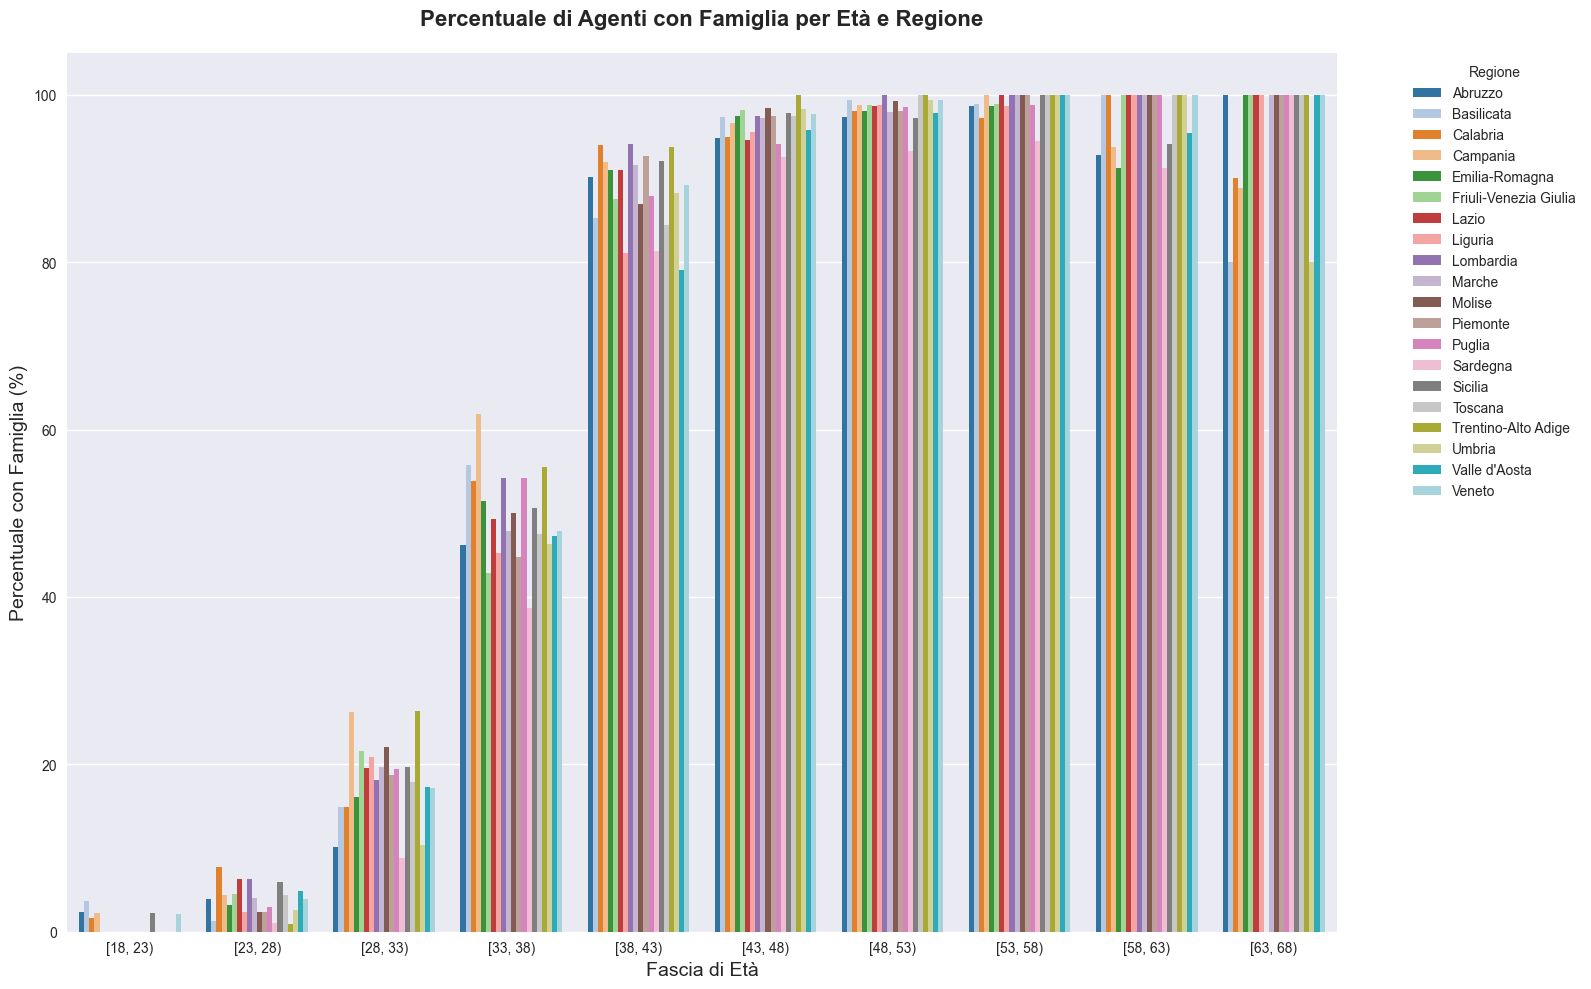

In [29]:
# Creazione della nuova colonna fascia_eta2 con intervalli di 5 anni
df_agenti_unici['fascia_eta2'] = pd.cut(df_agenti_unici['eta'], bins=range(18, 70, 5), right=False)

# Calcolo della percentuale di agenti con famiglia per età e regione
grouped_eta_regione = df_agenti_unici.groupby(['fascia_eta2', 'origine'])['famiglia'].mean().reset_index()
grouped_eta_regione['percentuale_famiglia'] = grouped_eta_regione['famiglia'] * 100

# Creazione del grafico a barre semplificato
fig, ax = plt.subplots(figsize=(16, 10))
sns.barplot(data=grouped_eta_regione, x='fascia_eta2', y='percentuale_famiglia', hue='origine', 
        palette='tab20', errorbar=None, ax=ax)

# Personalizzazione del grafico
ax.set_title('Percentuale di Agenti con Famiglia per Età e Regione', 
            fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Fascia di Età', fontsize=14)
ax.set_ylabel('Percentuale con Famiglia (%)', fontsize=14)
ax.legend(title='Regione', bbox_to_anchor=(1.05, 1), loc='upper left')

# Regolazione layout
plt.tight_layout()
plt.show()


In [30]:
# VISUALIZZAZIONI INTERATTIVE - SEZIONE CORRETTA
# ============================================================================

"""Crea mappa interattiva dei flussi migratori"""
print("\n🗺️ Creazione Mappa Interattiva...")

# Prima verifichiamo che tipo di regioni abbiamo nei dati
print("Colonne disponibili in df_emigrazioni:", df_emigrazioni.columns.tolist())
print("Colonne disponibili in df_longitudinale:", df_longitudinale.columns.tolist())

# Analizziamo i valori unici nelle colonne origine
print(f"\nRegioni di origine uniche in df_emigrazioni: {df_emigrazioni['origine'].nunique()}")
print("Esempi:", df_emigrazioni['origine'].unique()[:10])
print(f"\nRegioni di origine uniche in df_longitudinale: {df_longitudinale['origine'].nunique()}")
print("Esempi:", df_longitudinale['origine'].unique()[:10])

regione_col = 'origine'

# Statistiche per regione usando i dati reali
print(f"\nCalcolo statistiche per regione usando colonna: {regione_col}")

# Prima controlliamo se ci sono valori NaN nella colonna origine
nan_emigrazioni = df_emigrazioni[regione_col].isnull().sum()
nan_longitudinale = df_longitudinale[regione_col].isnull().sum()
print(f"Valori NaN in {regione_col} - emigrazioni: {nan_emigrazioni}, longitudinale: {nan_longitudinale}")

# Rimuoviamo eventuali righe con NaN nelle colonne regione
df_emigrazioni_clean = df_emigrazioni.dropna(subset=[regione_col])
df_longitudinale_clean = df_longitudinale.dropna(subset=[regione_col])

print(f"Dopo pulizia NaN - emigrazioni: {len(df_emigrazioni_clean)}, longitudinale: {len(df_longitudinale_clean)}")

# CALCOLO CORRETTO DELLE STATISTICHE PER REGIONE
# ============================================================================

# 1. Totale agenti per regione (dal dataset longitudinale)
agenti_per_regione = df_longitudinale_clean.groupby(regione_col)['id_agente'].nunique()
print(f"Agenti unici per regione calcolati: {len(agenti_per_regione)} regioni")

# 2. Emigranti per regione
emigranti_per_regione = df_emigrazioni_clean.groupby(regione_col).size()
print(f"Emigranti per regione calcolati: {len(emigranti_per_regione)} regioni")

# 3. Immigranti per regione (se disponibile colonna destinazione)
immigranti_per_regione = pd.Series(dtype=int)
if 'destinazione' in df_emigrazioni_clean.columns:
    immigranti_per_regione = df_emigrazioni_clean.groupby('destinazione').size()
    print(f"Immigranti per regione calcolati: {len(immigranti_per_regione)} regioni")
else:
    print("⚠️ Colonna 'destinazione' non trovata - immigranti non calcolabili")

# 4. Età media per regione
eta_media_per_regione = df_longitudinale_clean.groupby(regione_col)['eta'].mean()

# Combina tutti i dati
statistiche_regione = pd.DataFrame(index=agenti_per_regione.index)
statistiche_regione['totale_agenti'] = agenti_per_regione
statistiche_regione['emigrati'] = emigranti_per_regione.reindex(statistiche_regione.index, fill_value=0)
statistiche_regione['immigrati'] = immigranti_per_regione.reindex(statistiche_regione.index, fill_value=0)
statistiche_regione['eta_media'] = eta_media_per_regione.reindex(statistiche_regione.index, fill_value=0)

# Calcola tassi
statistiche_regione['tasso_emigrazione'] = (statistiche_regione['emigrati'] / statistiche_regione['totale_agenti'] * 100).round(1)
statistiche_regione['tasso_immigrazione'] = (statistiche_regione['immigrati'] / statistiche_regione['totale_agenti'] * 100).round(1)

# Rimuovi eventuali NaN risultanti dai calcoli
statistiche_regione = statistiche_regione.fillna(0)


# Preparazione dati per mappa con controllo più robusto
map_data = []
for regione, stats in statistiche_regione.iterrows():
    if regione in COORDINATE_REGIONI:
        lat, lon = COORDINATE_REGIONI[regione]
        
        # Gestione sicura dei valori, convertendo NaN in 0
        totale_agenti = int(stats['totale_agenti']) if not pd.isna(stats['totale_agenti']) else 0
        emigrati = int(stats['emigrati']) if not pd.isna(stats['emigrati']) else 0
        immigrati = int(stats['immigrati']) if not pd.isna(stats['immigrati']) else 0
        tasso_emigr = float(stats['tasso_emigrazione']) if not pd.isna(stats['tasso_emigrazione']) else 0.0
        tasso_immigr = float(stats['tasso_immigrazione']) if not pd.isna(stats['tasso_immigrazione']) else 0.0
        eta_media = float(stats['eta_media']) if not pd.isna(stats['eta_media']) else 0.0
        
        map_data.append({
            'regione': regione,
            'lat': lat,
            'lon': lon,
            'totale_agenti': totale_agenti,
            'emigrati': emigrati,
            'immigrati': immigrati,
            'tasso_emigrazione': tasso_emigr,
            'tasso_immigrazione': tasso_immigr,
            'eta_media': eta_media
        })
    else:
        print(f" Regione '{regione}' non trovata nelle coordinate")

map_df = pd.DataFrame(map_data)

# Pulizia dati: rimuovi eventuali NaN e valori infiniti
map_df = map_df.dropna()
map_df = map_df.replace([np.inf, -np.inf], 0)

# Assicurati che non ci siano valori negativi
map_df['emigrati'] = map_df['emigrati'].clip(lower=0)
map_df['immigrati'] = map_df['immigrati'].clip(lower=0)
map_df['tasso_emigrazione'] = map_df['tasso_emigrazione'].clip(lower=0)
map_df['tasso_immigrazione'] = map_df['tasso_immigrazione'].clip(lower=0)

# Normalizzazione dimensioni per la mappa
# Dimensione basata su emigrati (range 10-50)
map_df['size_emigrati'] = map_df['emigrati'].apply(lambda x: max(10, min(x*2 + 10, 50)))
# Colore basato su immigrati (range 0-100 per scala colori)
map_df['color_immigrati'] = map_df['immigrati']

# Mappa scatter con IMMIGRATI come colore e EMIGRATI come dimensione
try:
    fig_map = px.scatter_mapbox(
        map_df,
        lat='lat',
        lon='lon',
        size='size_emigrati',
        color='color_immigrati',
        hover_name='regione',
        hover_data={
            'totale_agenti': True,
            'emigrati': True, 
            'immigrati': True,
            'tasso_emigrazione': ':.1f',
            'tasso_immigrazione': ':.1f', 
            'eta_media': ':.1f',
            'size_emigrati': False,
            'color_immigrati': False
        },
        color_continuous_scale='Blues',  # Blu per immigrati
        size_max=40,
        zoom=5.5,
        center={'lat': 42.5, 'lon': 12.5},
        title='Mappa Flussi Migratori (Colore=Immigrati, Dimensione=Emigrati)',
        labels={
            'color_immigrati': 'Immigrati',
            'size_emigrati': 'Dimensione (Emigrati)',
            'totale_agenti': 'Tot. Agenti',
            'emigrati': 'Emigranti',
            'immigrati': 'Immigranti',
            'tasso_emigrazione': 'Tasso Emigr. (%)',
            'tasso_immigrazione': 'Tasso Immigr. (%)',
            'eta_media': 'Età Media'
        }
    )
    
    fig_map.update_layout(
        mapbox_style="open-street-map",
        height=600,
        font=dict(size=12),
        margin=dict(l=0, r=5, t=35, b=0),
        coloraxis_colorbar=dict(title="Immigrati")
    )
    
    # Aggiungi annotazione per spiegare la visualizzazione
    fig_map.add_annotation(
        text="📊 Dimensione punti = Emigrati | 🎨 Colore punti = Immigrati",
        showarrow=False,
        x=0, y=1, xref="paper", yref="paper",
        xanchor="left", yanchor="top",
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="gray",
        borderwidth=1,
        font=dict(size=10)
    )
    
    fig_map.show()
    print("✅ Mappa creata con successo!")
    
except Exception as e:
    print(f"⚠️ Errore nella creazione della mappa: {e}")
    print("Creo una mappa semplificata...")
    
    # Mappa di backup più semplice
    fig_map_simple = go.Figure(go.Scattermapbox(
        lat=map_df['lat'],
        lon=map_df['lon'],
        mode='markers',
        marker=dict(
            size=map_df['size_emigrati'],
            color=map_df['color_immigrati'],
            colorscale='Blues',
            showscale=True,
            colorbar=dict(title="Immigrati")
        ),
        text=map_df['regione'],
        hovertemplate='<b>%{text}</b><br>' +
                     'Tot. Agenti: %{customdata[0]}<br>' +
                     'Emigrati: %{customdata[1]}<br>' +
                     'Immigrati: %{customdata[2]}<br>' +
                     'Tasso Emigr.: %{customdata[3]:.1f}%<br>' +
                     'Tasso Immigr.: %{customdata[4]:.1f}%<br>' +
                     '<extra></extra>',
        customdata=np.column_stack((
            map_df['totale_agenti'], 
            map_df['emigrati'], 
            map_df['immigrati'],
            map_df['tasso_emigrazione'],
            map_df['tasso_immigrazione']
        ))
    ))
    
    fig_map_simple.update_layout(
        mapbox=dict(
            style="open-street-map",
            zoom=5.5,
            center=dict(lat=42.5, lon=12.5)
        ),
        height=800,
        title="Mappa Flussi Migratori (Dimensione=Emigrati, Colore=Immigrati)",
        margin=dict(l=0, r=2.5, t=35, b=0)
    )
    
    fig_map_simple.show()


🗺️ Creazione Mappa Interattiva...
Colonne disponibili in df_emigrazioni: ['id_agente', 'categoria', 'origine', 'destinazione', 'famiglia', 'anni_stab', 'attrattivita', 'soglia', 'eta', 'emigrato', 'gravity', 'pp', 'uty_T', 'anno']
Colonne disponibili in df_longitudinale: ['id_agente', 'categoria', 'origine', 'destinazione', 'famiglia', 'anni_stab', 'attrattivita', 'soglia', 'eta', 'emigrato', 'gravity', 'pp', 'uty_T', 'anno', 'diff_attr_soglia']

Regioni di origine uniche in df_emigrazioni: 13
Esempi: ['Abruzzo' 'Sicilia' 'Campania' 'Molise' "Valle d'Aosta" 'Liguria'
 'Veneto' 'Piemonte' 'Basilicata' 'Toscana']

Regioni di origine uniche in df_longitudinale: 20
Esempi: ['Molise' 'Lazio' 'Trentino-Alto Adige' 'Liguria' 'Friuli-Venezia Giulia'
 'Campania' 'Piemonte' 'Marche' "Valle d'Aosta" 'Veneto']

Calcolo statistiche per regione usando colonna: origine
Valori NaN in origine - emigrazioni: 0, longitudinale: 0
Dopo pulizia NaN - emigrazioni: 232, longitudinale: 40000
Agenti unici per 

✅ Mappa creata con successo!


In [31]:

"""Crea network graph dei flussi migratori"""
print("\n🕸️ Creazione Network Graph...")

flussi = df_emigrazioni.groupby(['origine', 'destinazione']).size().reset_index(name='count')

G = nx.from_pandas_edgelist(flussi, source='origine', target='destinazione', 
                            edge_attr='count', create_using=nx.DiGraph())
...

# Posizionamento nodi
pos = nx.spring_layout(G, k=3, iterations=50)

# Preparazione dati per plotly
edge_x = []
edge_y = []
edge_info = []

for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])
    weight = G[edge[0]][edge[1]]['count']
    edge_info.append(f"{edge[0]} → {edge[1]}: {weight}")

# Nodi
node_x = []
node_y = []
node_info = []
node_text = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)
    
    # Info del nodo
    in_degree = G.in_degree(node, weight='count')
    out_degree = G.out_degree(node, weight='count')
    node_info.append(f"{node}<br>In: {in_degree}<br>Out: {out_degree}")

# Creazione grafico
fig_network = go.Figure()

# Edges
fig_network.add_trace(go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines'
))

# Nodes
fig_network.add_trace(go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    hoverinfo='text',
    hovertext=node_info,
    text=node_text,
    textposition="middle center",
    marker=dict(
        size=20,
        color='lightblue',
        line=dict(width=2, color='darkblue')
    )
))

fig_network.update_layout(
    title={
    'text': 'Titolo del grafico',
    'font': {'size': 17}
    },
    showlegend=False,
    hovermode='closest',
    margin=dict(b=20,l=5,r=5,t=40),
    annotations=[ dict(
        text="Dimensione nodi: flussi in entrata e uscita",
        showarrow=False,
        xref="paper", yref="paper",
        x=0.005, y=-0.002,
        xanchor='left', yanchor='bottom',
        font=dict(color='grey', size=12)
    )],
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    height=600
)

fig_network.show()



🕸️ Creazione Network Graph...



🔮 Analisi Predittiva...
📊 CORRELAZIONI CON EMIGRAZIONE:
  attrattivita: 0.1402
  gravity: 0.0773
  anni_stab: -0.0804
  eta: -0.1060
  soglia: -0.1075


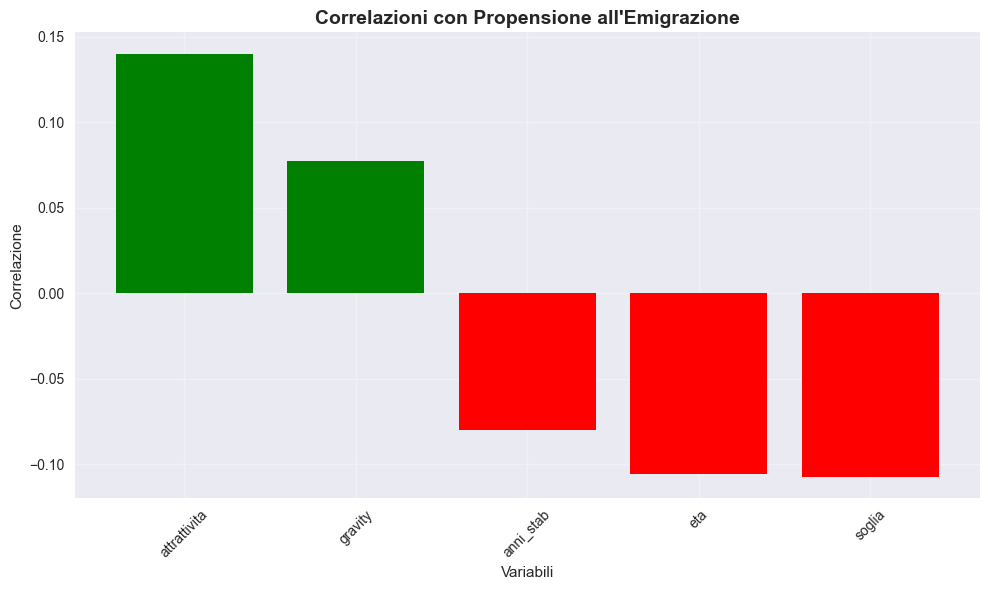


🎯 Analisi Cluster...
📊 CARATTERISTICHE CLUSTER:

  Cluster 0 (4062 agenti):
    Tasso emigrazione: 2.4%
    Età media: 28.6
    Attrattività media: 0.3977
    Anni stabilità media: 4.0
    Categorie principali: {'Lavoratore_Diploma': 2675, 'Lavoratore_Laurea': 989}

  Cluster 1 (906 agenti):
    Tasso emigrazione: 1.8%
    Età media: 41.5
    Attrattività media: 0.2824
    Anni stabilità media: 10.0
    Categorie principali: {'Lavoratore_Diploma': 602, 'Lavoratore_Laurea': 268}

  Cluster 2 (8950 agenti):
    Tasso emigrazione: 0.0%
    Età media: 39.6
    Attrattività media: 0.0548
    Anni stabilità media: 5.8
    Categorie principali: {'Lavoratore_Diploma': 5391, 'Lavoratore_Laurea': 2782}

  Cluster 3 (6082 agenti):
    Tasso emigrazione: 0.0%
    Età media: 48.1
    Attrattività media: 0.1122
    Anni stabilità media: 20.3
    Categorie principali: {'Lavoratore_Diploma': 4531, 'Lavoratore_Laurea': 1551}


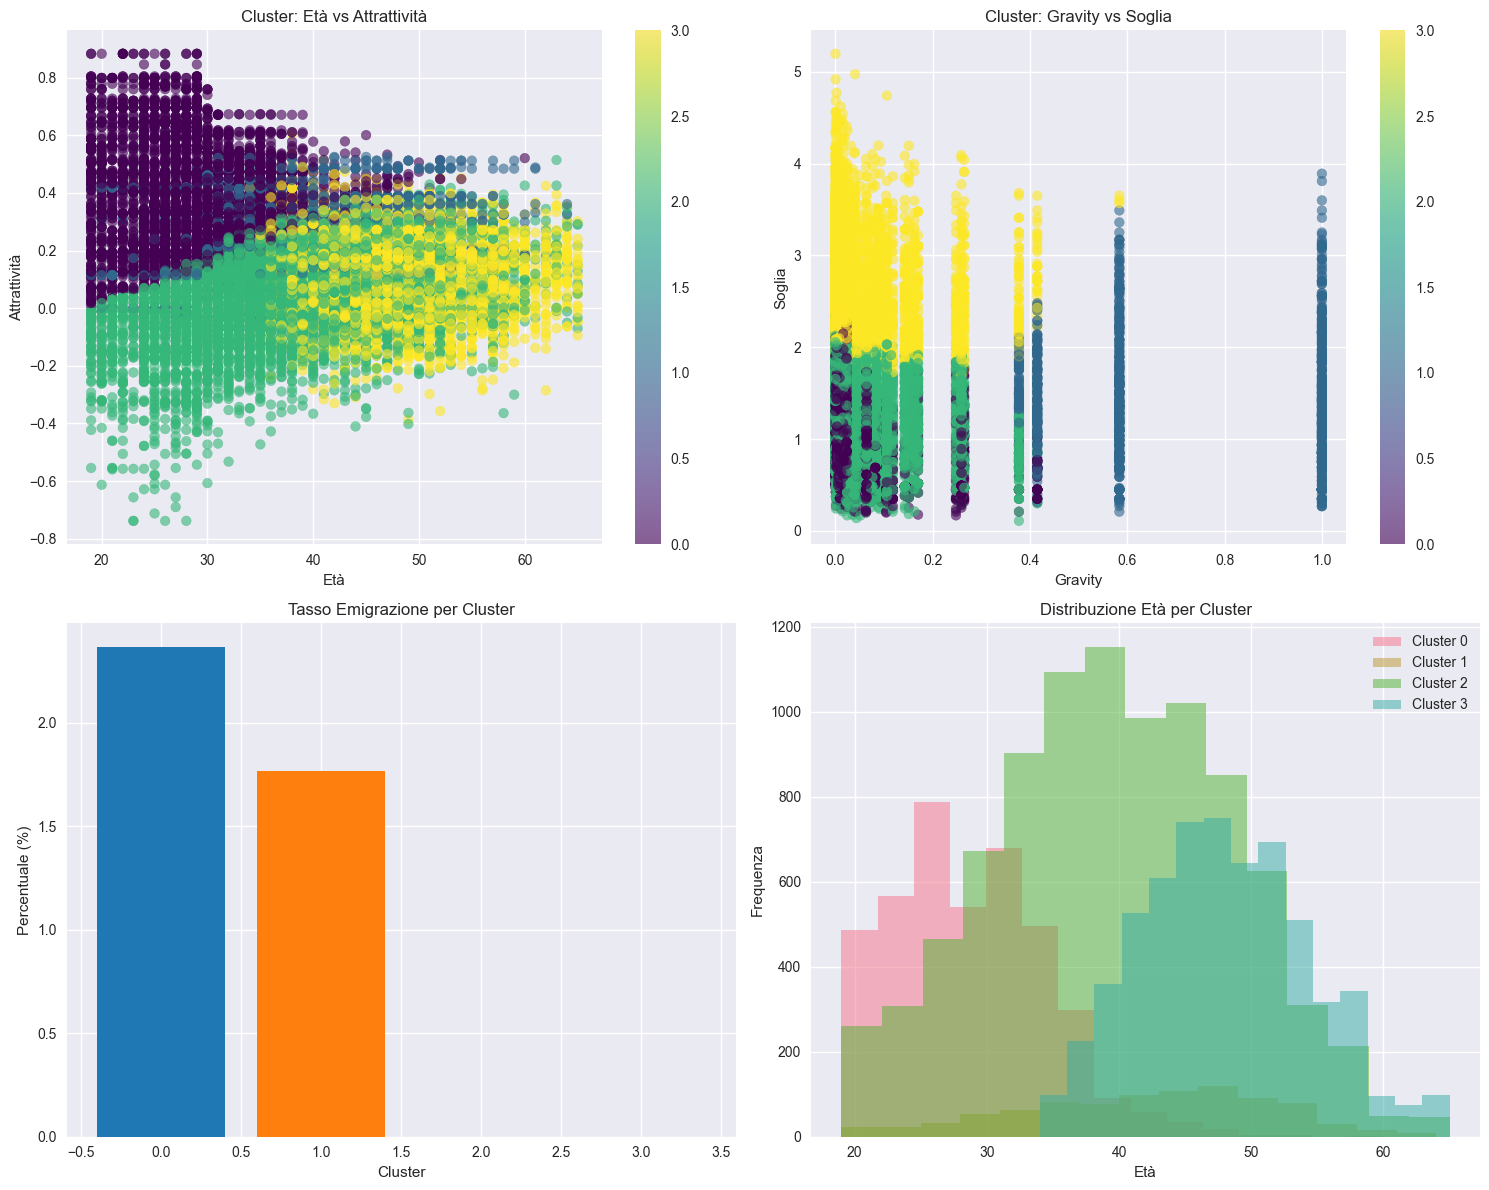

In [32]:

"""Analisi predittiva semplice"""
print("\n🔮 Analisi Predittiva...")

# Preparazione dati
X = df_agenti_unici[['eta', 'attrattivita', 'gravity', 'soglia', 'anni_stab']].fillna(0)
y = df_agenti_unici['emigrato']

# Correlazioni con emigrazione
correlazioni = X.corrwith(y).sort_values(ascending=False)

print("📊 CORRELAZIONI CON EMIGRAZIONE:")
for feature, corr in correlazioni.items():
    print(f"  {feature}: {corr:.4f}")

# Visualizzazione correlazioni
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
bars = ax.bar(correlazioni.index, correlazioni.values, 
                color=['green' if x > 0 else 'red' for x in correlazioni.values])
ax.set_title('Correlazioni con Propensione all\'Emigrazione', fontsize=14, fontweight='bold')
ax.set_ylabel('Correlazione')
ax.set_xlabel('Variabili')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




"""Analisi cluster degli agenti"""
print("\n🎯 Analisi Cluster...")

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Preparazione dati
features = ['eta', 'attrattivita', 'gravity', 'soglia', 'anni_stab']
X = df_agenti_unici[features].fillna(0)

# Standardizzazione
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Aggiunta cluster al dataframe
df_cluster = df_agenti_unici.copy()
df_cluster['cluster'] = clusters

# Analisi cluster
print("📊 CARATTERISTICHE CLUSTER:")
for cluster in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == cluster]
    tasso_emigrazione = cluster_data['emigrato'].mean() * 100
    print(f"\n  Cluster {cluster} ({len(cluster_data)} agenti):")
    print(f"    Tasso emigrazione: {tasso_emigrazione:.1f}%")
    print(f"    Età media: {cluster_data['eta'].mean():.1f}")
    print(f"    Attrattività media: {cluster_data['attrattivita'].mean():.4f}")
    print(f"    Anni stabilità media: {cluster_data['anni_stab'].mean():.1f}")
    print(f"    Categorie principali: {cluster_data['categoria'].value_counts().head(2).to_dict()}")

# Visualizzazione cluster
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot età vs attrattività
scatter = axes[0, 0].scatter(df_cluster['eta'], df_cluster['attrattivita'], 
                            c=clusters, cmap='viridis', alpha=0.6)
axes[0, 0].set_title('Cluster: Età vs Attrattività')
axes[0, 0].set_xlabel('Età')
axes[0, 0].set_ylabel('Attrattività')
plt.colorbar(scatter, ax=axes[0, 0])

# Scatter plot gravity vs soglia
scatter = axes[0, 1].scatter(df_cluster['gravity'], df_cluster['soglia'], 
                            c=clusters, cmap='viridis', alpha=0.6)
axes[0, 1].set_title('Cluster: Gravity vs Soglia')
axes[0, 1].set_xlabel('Gravity')
axes[0, 1].set_ylabel('Soglia')
plt.colorbar(scatter, ax=axes[0, 1])

# Tasso emigrazione per cluster
emigrazione_cluster = df_cluster.groupby('cluster')['emigrato'].mean() * 100
axes[1, 0].bar(emigrazione_cluster.index, emigrazione_cluster.values, 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1, 0].set_title('Tasso Emigrazione per Cluster')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Percentuale (%)')

# Distribuzione età per cluster
for cluster in range(4):
    cluster_data = df_cluster[df_cluster['cluster'] == cluster]
    axes[1, 1].hist(cluster_data['eta'], alpha=0.5, label=f'Cluster {cluster}', bins=15)
axes[1, 1].set_title('Distribuzione Età per Cluster')
axes[1, 1].set_xlabel('Età')
axes[1, 1].set_ylabel('Frequenza')
axes[1, 1].legend()

plt.tight_layout()
plt.show()